In [11]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped, 
    square_input_wave,
    InterpolatedSample2D,
    KrivanekLens, 
    Biprism,
    sample_input_wave,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.utils import remove_phase_ramp
from libertem_holo.base.filters import clipped

jax.config.update("jax_enable_x64", True)

In [12]:
def make_sample_interpolant(input_cube_xy, input_cube_side_length, input_cube_x_tilt, voltage_eV):
    k = 2 * np.pi / energy2wavelength(voltage_eV)
    simulation_side_length = input_cube_side_length * 2
    cube_fraction = input_cube_side_length / simulation_side_length
    sample_fields, sample_x_coords, sample_y_coords, sample_z_coords = make_tilted_uniform_cube(
        tilt_x=input_cube_x_tilt,
        L=simulation_side_length,
        cube_fraction=cube_fraction,
        x0=input_cube_xy[0],
        y0=input_cube_xy[1],
        B0=0.4,
        V0=0.01,
        amplitude_dampening=1,
    )
    sample_amp, sample_phase_shift = project_phase_along_z(
        fields=sample_fields,
        z_coords=sample_z_coords,
        voltage=voltage_eV,
    )
    sample_field = sample_amp * np.exp(1j * sample_phase_shift / k)

    sample_interpolator = InterpolatedSample2D.from_array(sample=sample_field, x_coords=sample_x_coords, y_coords=sample_y_coords, z=0.0, method='cubic').interpolator

    return sample_interpolator, sample_x_coords, sample_y_coords, sample_field

In [13]:
def run_model(input_window_width_m=1e-6,
              fringe_spacing=6e-9, # Desired fringe spacing in metres
              num_pixels=512, # Number of pixels in detector
              voltage_eV=200e3,
              input_cube_xy=(0.0, 0.0),
              input_cube_x_tilt=0.0,  # radians
              input_cube_side_length=50e-9,  # metres
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-1, # Must be negative
              defocus=0.0,
              beam_waist=2e-9,
              overlap_factor=2.0,
              detector_rotation=0.0):

    # Create input field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels
    print(pixel_size)

    sample_interpolator, sample_x_coords, sample_y_coords, sample_field = make_sample_interpolant(
        input_cube_xy=input_cube_xy,
        input_cube_side_length=input_cube_side_length,
        input_cube_x_tilt=input_cube_x_tilt,
        voltage_eV=voltage_eV,
    )
    sample_pixel_size = sample_x_coords[1] - sample_x_coords[0]
    print(f"Sample pixel size: {sample_pixel_size:.2e} m")

    rays_in = sample_input_wave(voltage=voltage_eV,
                                aperture_length=input_window_width_m * 1.0,
                                waist=beam_waist,
                                overlap_factor=overlap_factor,
                                z0=defocus,
                                sample_interpolator=sample_interpolator)
    
    
    input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(np.abs(input_field), extent=input_grid.extent, cmap='inferno')
    axs[0].set_title('Input Field Amplitude')
    axs[1].imshow(np.angle(input_field), extent=input_grid.extent, cmap='twilight')
    axs[1].set_title('Input Field Phase')
    plt.tight_layout()

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    z1, z2 = map(abs, (z1, z2))  # Make distances positive

    # Calculate biprism strength needed for desired fringe spacing
    # Biprism is placed halfway between the objective lens focal plane (where the source is)
    # and it's image plane, where the friges will be observed.
    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2 
    a = biprism_z - (z1 + obj_focal_length)
    b = ((z1 + z2) - biprism_z)

    # Quick assert to check distances add up
    L = a + b
    assert L == z1 + z2 - (z1 + obj_focal_length)

    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        phi12=0.0,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-15)

    detector = Detector(
        z=z1 + z2,
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
        rotation=detector_rotation
    )
    
    extent = detector.extent
    det_xy_coords_1d = detector.coords_1d

    rays_out_with_sample = run_to_end_vmapped(rays_in, (objective_lens, biprism, detector))
    output_holo_with_sample = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_sample, detector).block_until_ready()

    fig, axs = plt.subplots(1, 1)
    axs.imshow(np.abs(output_holo_with_sample), cmap='gray')
    axs.set_title('Hologram Intensity With Sample')
   
    return input_field, output_holo_with_sample, extent, det_xy_coords_1d, sample_field, sample_x_coords, sample_y_coords, k

2.44140625e-09
Sample pixel size: 2.35e-09 m


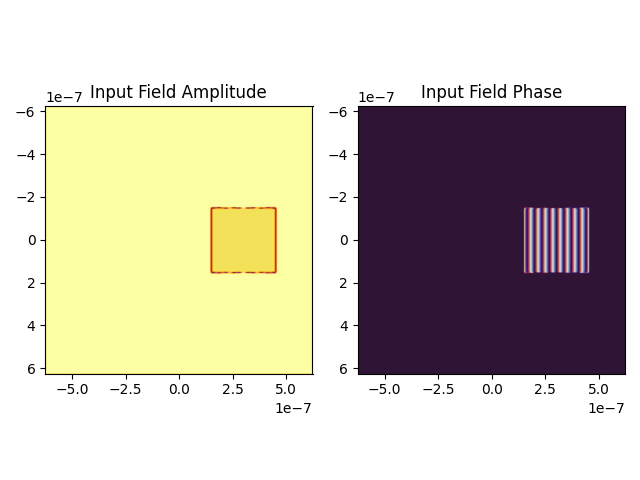

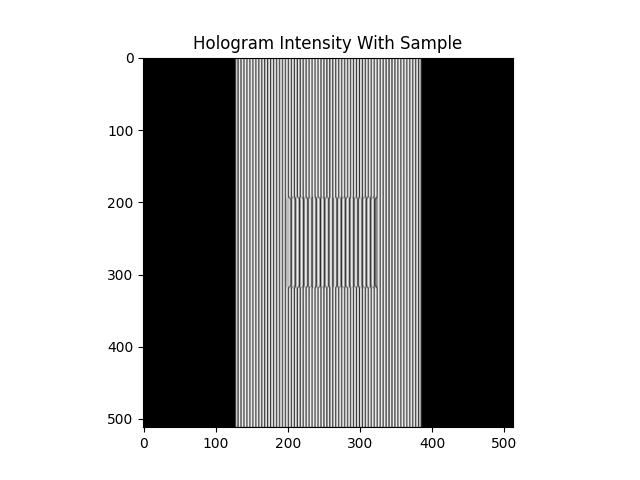

In [14]:
square_side_length = 300e-9
square_centre=(0.3e-6, 0.0e-6)
base_simulation_kwargs = dict(
    voltage_eV=200e3,
    input_window_width_m=1250e-9,
    fringe_spacing=10e-9,
    num_pixels=512,
    beam_waist=3e-9,
    input_cube_xy=square_centre,
    input_cube_side_length=square_side_length,
    input_cube_x_tilt=np.deg2rad(0),
    obj_magnification=-1,
    detector_rotation=0.0,
)

input_field_with_sample, output_holo_with_sample, extent, det_xy_coords_1d, sample_field, sample_x_coords, sample_y_coords, k = run_model(
    **base_simulation_kwargs
)

In [15]:
hologram = np.abs(output_holo_with_sample) ** 2

In [16]:
s_start = 129
s_row, s_col = slice(s_start, s_start+256), slice(s_start, s_start+256)

hologram = hologram[s_row, s_col]
out_shape = hologram.shape

Select a hologram phase ramp region by drawing a rectangle on the hologram image below. Select an area that contains only hologram fringes and no sample features.

In [17]:
from libertem_ui.figure import ApertureFigure

fig = ApertureFigure.new(hologram)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout


BokehModel(combine_events=True, render_bundle={'docs_json': {'50eb9e6a-45cd-486e-bb35-98bca6649904': {'version…

In [19]:
ramp_roi = fig.get_mask_rect_as_slices(hologram.shape)
print(ramp_roi, hologram.shape)

[(slice(21, 32, None), slice(8, 246, None))] (256, 256)


In [20]:
holo_params = HoloParams.from_hologram(
    hologram=hologram,
    out_shape=out_shape,
)

sb_pos = 255, 44
slice_fft = get_slice_fft(sig_shape=hologram.shape, out_shape=out_shape)
wave_obj = reconstruct_frame(
    frame=hologram,
    sb_pos=sb_pos,
    slice_fft=slice_fft,
    aperture=holo_params.aperture,
)

remove_phase_ramp(np.angle(wave_obj))

phase, _, _ = remove_phase_ramp(phase_unwrap(np.angle(wave_obj)), roi=ramp_roi[0])
phase = phase - np.min(np.abs(phase))
fft = np.fft.fft2(hologram)
img = np.abs(fft)


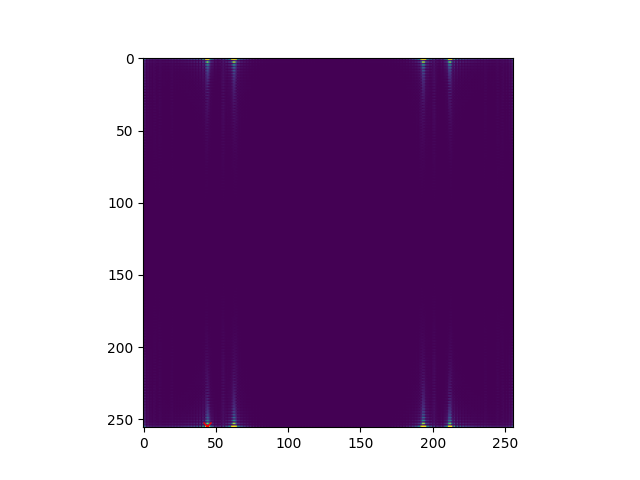

In [21]:
plt.figure()
plt.imshow(img, vmin=np.min(clipped(img)), vmax=np.max(clipped(img)))
plt.plot(sb_pos[1], sb_pos[0], 'rx')

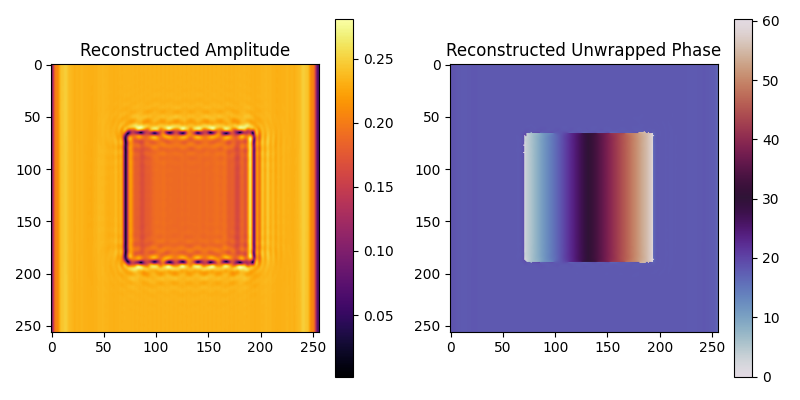

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
im0 = axs[0].imshow(np.abs(wave_obj), cmap='inferno')
axs[0].set_title('Reconstructed Amplitude')
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(phase, cmap='twilight')
axs[1].set_title('Reconstructed Unwrapped Phase')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()

In [23]:
from libertem_ui.figure import ApertureFigure

fig = ApertureFigure.new(phase)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout

BokehModel(combine_events=True, render_bundle={'docs_json': {'8675435c-f1c1-4229-8d20-87de75f0d608': {'version…

In [24]:
measured_phase_roi = fig.get_mask_rect_as_slices(phase.shape)

In [27]:
from libertem_ui.figure import ApertureFigure
input_field_phase = phase_unwrap(input_field_with_sample)
fig = ApertureFigure.new(input_field_phase)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout

BokehModel(combine_events=True, render_bundle={'docs_json': {'4af3554e-b3b8-42b2-b61a-2f79a14147bb': {'version…

In [28]:
ground_truth_phase_roi = fig.get_mask_rect_as_slices(input_field_phase.shape)

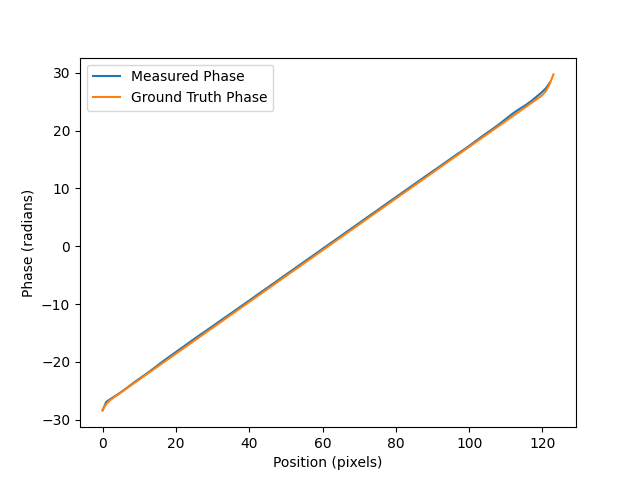

In [30]:

ground_truth_phase_cross_section = np.mean(input_field_phase[ground_truth_phase_roi[0]], axis=0)
ground_truth_phase_cross_section = ground_truth_phase_cross_section - np.mean(ground_truth_phase_cross_section)

measured_phase_cross_section = np.mean(phase[measured_phase_roi[0]], axis=0)
measured_phase_cross_section = measured_phase_cross_section - np.mean(measured_phase_cross_section)

plt.figure()
plt.plot(measured_phase_cross_section, label='Measured Phase')
plt.plot(ground_truth_phase_cross_section, label='Ground Truth Phase')  
plt.xlabel('Position (pixels)')
plt.ylabel('Phase (radians)')
plt.legend()